<a href="https://colab.research.google.com/github/RajeshRanaGiet/AML-LAB/blob/main/Experiment%205/AML_EXP_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Enter the x feature : 7,8,2,1
Enter the y feature : 5,4,9,1
Weights: 0.044371435583473874
Bias: 4.4870784687400525


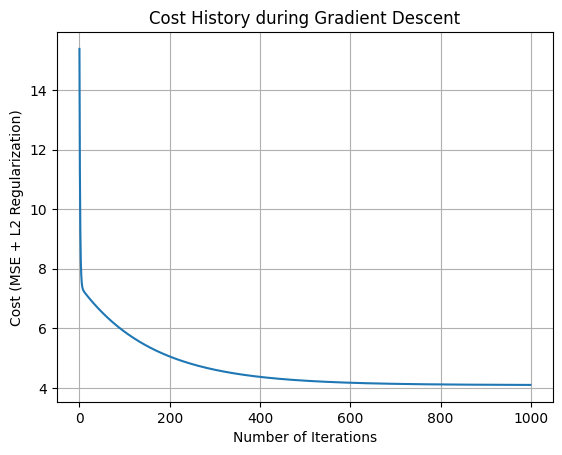

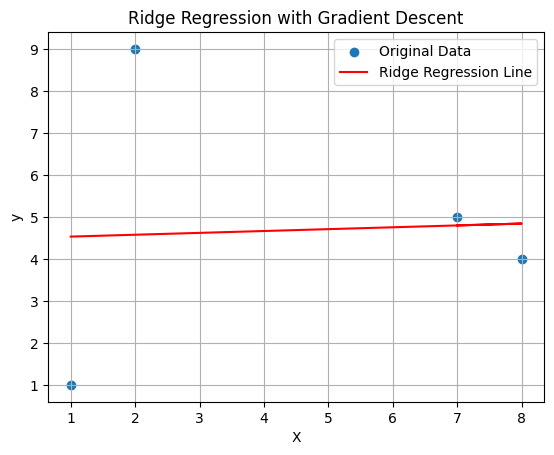

In [18]:
import numpy as np
import matplotlib.pyplot as plt

def ridge_regression_gd(X, y, learning_rate, n_iterations, lambda_param):
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    bias = 0

    cost_history = []
    for i in range(n_iterations):
        y_predicted = np.dot(X, weights) + bias
        dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y)) + (2 * lambda_param * weights)
        db = (1 / n_samples) * np.sum(y_predicted - y)
        weights = weights - learning_rate * dw
        bias = bias - learning_rate * db
        cost = (1 / (2 * n_samples)) * np.sum((y_predicted - y)**2) + (lambda_param * np.sum(weights**2))
        cost_history.append(cost)

    return weights, bias, cost_history

x_input = input("Enter the x feature : ")
y_input = input("Enter the y feature : ")

X = np.array([float(val) for val in x_input.split(',')]).reshape(-1, 1)
y = np.array([float(val) for val in y_input.split(',')])
learning_rate = 0.01
n_iterations = 1000
lambda_param = 0.1

weights, bias, cost_history = ridge_regression_gd(X, y, learning_rate, n_iterations, lambda_param)

print(f"Weights: {weights[0]}")
print(f"Bias: {bias}")

plt.plot(range(n_iterations), cost_history)
plt.xlabel("Number of Iterations")
plt.ylabel("Cost (MSE + L2 Regularization)")
plt.title("Cost History during Gradient Descent")
plt.grid(True)
plt.show()

plt.scatter(X, y, label="Original Data")
plt.plot(X, np.dot(X, weights) + bias, color='red', label="Ridge Regression Line")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Ridge Regression with Gradient Descent")
plt.legend()
plt.grid(True)
plt.show()


Enter the x feature for Lasso : 1,2,3,4
Enter the y feature for Lasso : 5,2,3,6
Lasso Weights: 0.5306970981200794
Lasso Bias: 2.5805248377141696


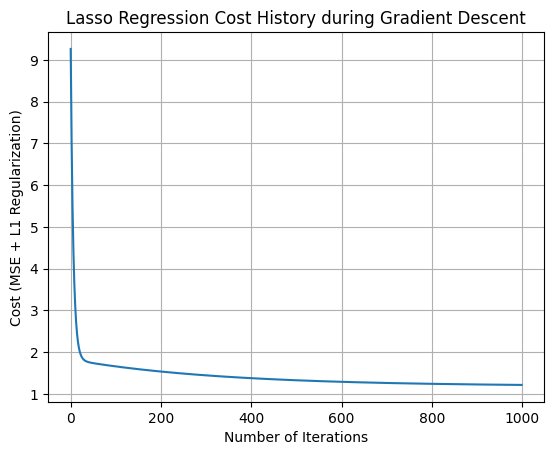

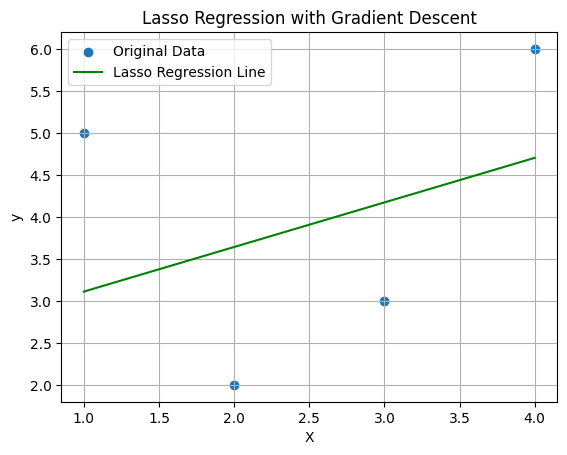

In [19]:
import numpy as np
import matplotlib.pyplot as plt

def lasso_regression_gd(X, y, learning_rate, n_iterations, lambda_param):
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    bias = 0

    cost_history = []
    for i in range(n_iterations):
        y_predicted = np.dot(X, weights) + bias

        dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y)) + lambda_param * np.sign(weights)
        db = (1 / n_samples) * np.sum(y_predicted - y)

        weights = weights - learning_rate * dw
        bias = bias - learning_rate * db
        cost = (1 / (2 * n_samples)) * np.sum((y_predicted - y)**2) + (lambda_param * np.sum(np.abs(weights)))
        cost_history.append(cost)

    return weights, bias, cost_history

x_lasso_input = input("Enter the x feature for Lasso : ")
y_lasso_input = input("Enter the y feature for Lasso : ")

X_lasso = np.array([float(val) for val in x_lasso_input.split(',')]).reshape(-1, 1)
y_lasso = np.array([float(val) for val in y_lasso_input.split(',')])

learning_rate_lasso = 0.01
n_iterations_lasso = 1000
lambda_param_lasso = 0.1

weights_lasso, bias_lasso, cost_history_lasso = lasso_regression_gd(X_lasso, y_lasso, learning_rate_lasso, n_iterations_lasso, lambda_param_lasso)

print(f"Lasso Weights: {weights_lasso[0]}")
print(f"Lasso Bias: {bias_lasso}")

plt.plot(range(n_iterations_lasso), cost_history_lasso)
plt.xlabel("Number of Iterations")
plt.ylabel("Cost (MSE + L1 Regularization)")
plt.title("Lasso Regression Cost History during Gradient Descent")
plt.grid(True)
plt.show()


plt.scatter(X_lasso, y_lasso, label="Original Data")
plt.plot(X_lasso, np.dot(X_lasso, weights_lasso) + bias_lasso, color='green', label="Lasso Regression Line")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Lasso Regression with Gradient Descent")
plt.legend()
plt.grid(True)
plt.show()